# Stage 2 — Response Prediction Baselines

**Project:** Causal ML for Personalized Advertising  
**Primary outcome:** visit

Stage 1 established that randomized assignment to advertising increases visits on average. Stage 2 deliberately solves a different, conventional supervised-learning problem:

$$\hat\mu(X)=P(Y=1\mid X).$$

The model predicts **who will visit**, not **who will visit because of an ad**. That distinction is the bridge to uplift/CATE modeling.

## 1. Business question and leakage rules

A response model can help forecast demand, prioritize likely visitors, or serve as a benchmark. If it is used for ad targeting, however, it may rank "sure things"—users who would visit anyway—above persuadable users.

Only f0–f11 are used as predictors because they are available before the targeting decision.

| Excluded column | Why it is excluded |
|---|---|
| treatment | The future decision/experimental assignment, not a user feature |
| exposure | Post-treatment delivery variable; unavailable at decision time and a leakage risk |
| visit | Prediction target |
| conversion | Downstream outcome; using it would leak future information |

> **Key distinction:** A strong ROC-AUC demonstrates response ranking, not incrementality. Causal targeting must be evaluated with randomized treatment outcomes.

In [1]:
from pathlib import Path
import platform
import sys
import time
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import seaborn as sns

from IPython.display import display, Markdown
from sklearn import __version__ as sklearn_version
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.6f}')

print('Python       :', platform.python_version())
print('Executable   :', Path(sys.executable).name)
print('NumPy        :', np.__version__)
print('pandas       :', pd.__version__)
print('scikit-learn:', sklearn_version)
print('LightGBM     :', lgb.__version__)


Python       : 3.10.19
Executable   : python
NumPy        : 2.2.6
pandas       : 2.3.2
scikit-learn: 1.7.1
LightGBM     : 4.6.0


## 2. Load a deterministic one-million-row development sample

The full CSV has about 13.98 million rows. A fixed Bernoulli sample of roughly one million rows is large enough for stable prediction baselines and keeps the notebook laptop-friendly. The CSV is still streamed rather than loaded fully into memory.

This sample is only for model development. A final production-quality benchmark could retrain the winning specification on more rows.

In [2]:
def find_project_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / 'data' / 'criteo-uplift-v2.1.csv').exists():
            return candidate
    raise FileNotFoundError('Could not find data/criteo-uplift-v2.1.csv.')

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / 'data' / 'criteo-uplift-v2.1.csv'
FEATURES = [f'f{i}' for i in range(12)]
TARGET = 'visit'
KEEP_COLS = FEATURES + ['treatment', 'visit', 'conversion']
DTYPES = {
    **{c: 'float32' for c in FEATURES},
    'treatment': 'int8',
    'visit': 'int8',
    'conversion': 'int8',
}

EXPECTED_ROWS = 13_979_592
SAMPLE_TARGET = 1_000_000
CHUNK_SIZE = 500_000
RANDOM_SEED = 42
sample_probability = SAMPLE_TARGET / EXPECTED_ROWS

start = time.perf_counter()
rng = np.random.default_rng(RANDOM_SEED)
parts = []
rows_scanned = 0

for chunk in pd.read_csv(DATA_PATH, usecols=KEEP_COLS, dtype=DTYPES, chunksize=CHUNK_SIZE):
    rows_scanned += len(chunk)
    keep = rng.random(len(chunk)) < sample_probability
    parts.append(chunk.loc[keep].copy())

df = pd.concat(parts, ignore_index=True)
elapsed = time.perf_counter() - start

print(f'Scanned {rows_scanned:,} rows in {elapsed:.1f} seconds.')
print(f'Modeling sample: {len(df):,} rows ({len(df)/rows_scanned:.2%} of full data).')
print(f'Memory usage: {df.memory_usage(deep=True).sum()/1024**2:.1f} MiB')


Scanned 13,979,592 rows in 11.3 seconds.
Modeling sample: 999,453 rows (7.15% of full data).
Memory usage: 48.6 MiB


## 3. Train / validation / test design

- **60% train:** fit model parameters.
- **20% validation:** LightGBM early stopping and model development.
- **20% test:** one-time final evaluation and randomized policy sanity check.

The split is stratified jointly by treatment and visit so that rare outcomes and both experimental arms remain represented. The test set is never used for fitting or early stopping.

In [3]:
strata = df['treatment'].astype(str) + '_' + df[TARGET].astype(str)
train_df, temp_df = train_test_split(
    df,
    test_size=0.40,
    random_state=RANDOM_SEED,
    stratify=strata,
)
temp_strata = temp_df['treatment'].astype(str) + '_' + temp_df[TARGET].astype(str)
valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=RANDOM_SEED,
    stratify=temp_strata,
)

X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_valid, y_valid = valid_df[FEATURES], valid_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

split_summary = pd.DataFrame({
    name: {
        'rows': len(frame),
        'visit_rate': frame['visit'].mean(),
        'conversion_rate': frame['conversion'].mean(),
        'treatment_share': frame['treatment'].mean(),
    }
    for name, frame in [('train', train_df), ('validation', valid_df), ('test', test_df)]
}).T
display(split_summary)

assert not set(['treatment', 'exposure', 'visit', 'conversion']).intersection(X_train.columns)
assert len(train_df) + len(valid_df) + len(test_df) == len(df)
print('Leakage check passed. Model features:', FEATURES)


,rows,visit_rate,conversion_rate,treatment_share
train,"599,671.000000",0.046871,0.002838,0.850421
validation,"199,891.000000",0.046871,0.002982,0.850423
test,"199,891.000000",0.046871,0.002922,0.850418


Leakage check passed. Model features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']


## 4. Models

1. **Dummy prior:** no feature information; establishes metric floors.
2. **Logistic regression:** linear, standardized, interpretable baseline.
3. **Random forest:** nonlinear bagging baseline with conservative leaf size.
4. **LightGBM:** gradient-boosted trees, strong for large tabular datasets.

We do **not** use class_weight='balanced'. Reweighting can change the meaning of predicted probabilities and damage calibration. Ranking and probability quality are evaluated separately.

In [4]:
models = {
    'Dummy prior': DummyClassifier(strategy='prior'),
    'Logistic regression': Pipeline([
        ('scale', StandardScaler()),
        ('model', LogisticRegression(C=1.0, max_iter=500, solver='lbfgs')),
    ]),
    'Random forest': RandomForestClassifier(
        n_estimators=200,
        min_samples_leaf=100,
        max_features='sqrt',
        n_jobs=-1,
        random_state=RANDOM_SEED,
    ),
    'LightGBM': lgb.LGBMClassifier(
        objective='binary',
        n_estimators=600,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=200,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=-1,
    ),
}

fit_times = {}
for name, model in models.items():
    start = time.perf_counter()
    if name == 'LightGBM':
        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric='binary_logloss',
            callbacks=[lgb.early_stopping(40, verbose=False)],
        )
    else:
        model.fit(X_train, y_train)
    fit_times[name] = time.perf_counter() - start
    suffix = f', best_iteration={model.best_iteration_}' if name == 'LightGBM' else ''
    print(f'{name:20s}: {fit_times[name]:6.1f} seconds{suffix}')


Dummy prior         :    0.0 seconds


Logistic regression :    0.5 seconds


Random forest       :   16.6 seconds


LightGBM            :    2.1 seconds, best_iteration=136


## 5. Test-set metrics

- **ROC-AUC:** ranking across positive-negative pairs; can look strong under class imbalance.
- **PR-AUC / average precision:** more sensitive to performance on the rare positive class. The dummy baseline equals prevalence.
- **Log loss:** strongly penalizes confident wrong probabilities.
- **Brier score:** mean squared probability error; lower is better.
- **Top-decile lift:** visit rate among the top 10% scores divided by the overall visit rate.

No single metric is sufficient: ranking, probability accuracy, and business operating points answer different questions.

In [5]:
test_predictions = test_df[['treatment', 'visit', 'conversion']].copy()
metric_rows = []

for name, model in models.items():
    p = model.predict_proba(X_test)[:, 1]
    test_predictions[name] = p
    top10 = p >= np.quantile(p, 0.90)
    metric_rows.append({
        'model': name,
        'roc_auc': roc_auc_score(y_test, p),
        'pr_auc': average_precision_score(y_test, p),
        'log_loss': log_loss(y_test, p),
        'brier_score': brier_score_loss(y_test, p),
        'top_10pct_visit_rate': y_test.to_numpy()[top10].mean(),
        'top_decile_lift': y_test.to_numpy()[top10].mean() / y_test.mean(),
        'fit_seconds': fit_times[name],
    })

metrics = pd.DataFrame(metric_rows).set_index('model').sort_values('pr_auc', ascending=False)
display(metrics)

best_model_name = metrics.index[0]
print('Best model by test PR-AUC:', best_model_name)
print(f'Test prevalence / dummy PR-AUC: {y_test.mean():.4%}')


,roc_auc,pr_auc,log_loss,brier_score,top_10pct_visit_rate,top_decile_lift,fit_seconds
model,,,,,,,
LightGBM,0.945318,0.510011,0.103823,0.029957,0.365533,7.798774,2.114185
Random forest,0.944485,0.508651,0.104374,0.030056,0.363782,7.761418,16.616170
Logistic regression,0.929938,0.480794,0.111915,0.031482,0.354927,7.572506,0.514693
Dummy prior,0.500000,0.046871,0.189196,0.044674,0.046871,1.000000,0.010840


Best model by test PR-AUC: LightGBM
Test prevalence / dummy PR-AUC: 4.6871%


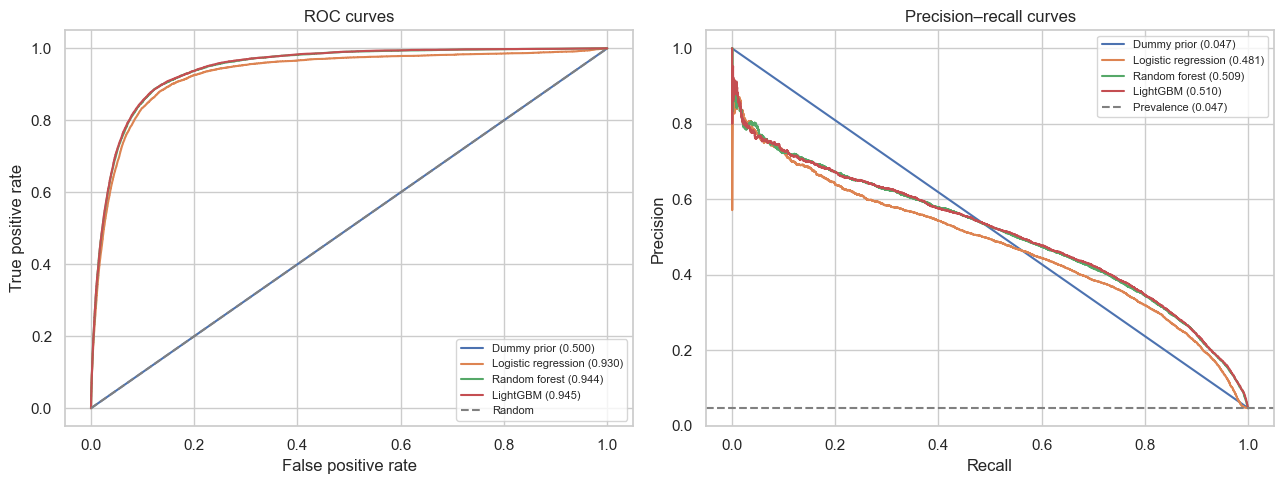

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for name in models:
    p = test_predictions[name].to_numpy()
    fpr, tpr, _ = roc_curve(y_test, p)
    precision, recall, _ = precision_recall_curve(y_test, p)
    axes[0].plot(fpr, tpr, label=f'{name} ({metrics.loc[name, "roc_auc"]:.3f})')
    axes[1].plot(recall, precision, label=f'{name} ({metrics.loc[name, "pr_auc"]:.3f})')

axes[0].plot([0, 1], [0, 1], '--', color='gray', label='Random')
axes[0].set(title='ROC curves', xlabel='False positive rate', ylabel='True positive rate')
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label=f'Prevalence ({y_test.mean():.3f})')
axes[1].set(title='Precision–recall curves', xlabel='Recall', ylabel='Precision')
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. Calibration

A calibrated model means that among users assigned probability 0.10, approximately 10% actually visit. Calibration matters for forecasting, capacity planning, expected-value decisions, and comparing probability to cost—not just ranking.

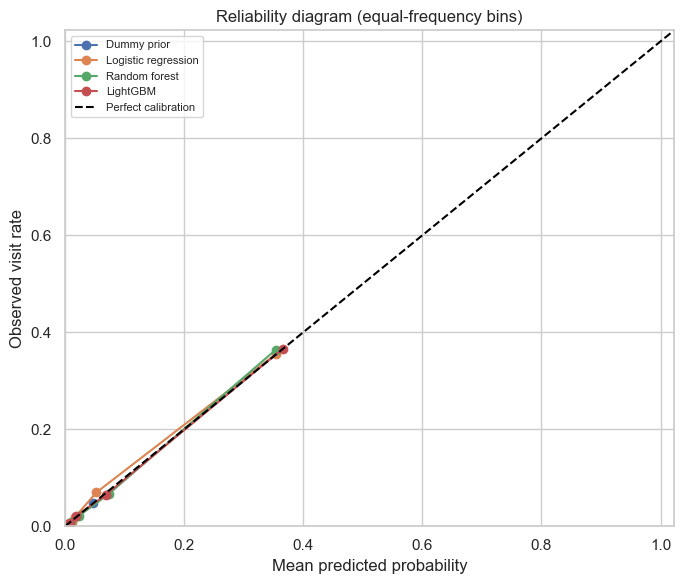

,mean_predicted_probability,observed_visit_rate
0,0.000600,0.000641
1,0.000725,0.000328
2,0.000861,0.000813
3,0.001165,0.000989
4,0.002269,0.002239
5,0.004647,0.004718
6,0.007987,0.007408
7,0.018889,0.021311
8,0.068571,0.064799
9,0.365220,0.365551


In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
calibration_tables = {}

for name in models:
    p = test_predictions[name].to_numpy()
    observed, predicted = calibration_curve(y_test, p, n_bins=10, strategy='quantile')
    calibration_tables[name] = pd.DataFrame({
        'mean_predicted_probability': predicted,
        'observed_visit_rate': observed,
    })
    ax.plot(predicted, observed, marker='o', label=name)

limit = max(test_predictions[list(models)].max().max(), y_test.mean()) * 1.05
ax.plot([0, limit], [0, limit], '--', color='black', label='Perfect calibration')
ax.set(
    title='Reliability diagram (equal-frequency bins)',
    xlabel='Mean predicted probability',
    ylabel='Observed visit rate',
    xlim=(0, limit),
    ylim=(0, limit),
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

display(calibration_tables[best_model_name])

## 7. Why a 0.5 classification threshold is unhelpful

The base visit rate is only about 4.7%. A probability model can rank users well while assigning almost nobody a probability above 0.5. Advertising usually has a budget or capacity constraint, so top-k targeting is a more relevant operating point than a universal 0.5 cutoff.

In [8]:
best_p = test_predictions[best_model_name].to_numpy()
pred_at_half = (best_p >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred_at_half)

top10_mask = best_p >= np.quantile(best_p, 0.90)
operating_points = pd.DataFrame({
    'rule': ['Probability >= 0.5', 'Top 10% by score'],
    'selected_share': [pred_at_half.mean(), top10_mask.mean()],
    'precision_visit_rate': [
        y_test.to_numpy()[pred_at_half == 1].mean() if pred_at_half.sum() else np.nan,
        y_test.to_numpy()[top10_mask].mean(),
    ],
    'recall_of_visitors': [
        ((pred_at_half == 1) & (y_test.to_numpy() == 1)).sum() / y_test.sum(),
        (top10_mask & (y_test.to_numpy() == 1)).sum() / y_test.sum(),
    ],
})

display(pd.DataFrame(cm, index=['actual 0', 'actual 1'], columns=['predicted 0', 'predicted 1']))
display(operating_points)


,predicted 0,predicted 1
actual 0,188630,1892
actual 1,6309,3060


,rule,selected_share,precision_visit_rate,recall_of_visitors
0,Probability >= 0.5,0.024774,0.617932,0.326609
1,Top 10% by score,0.100005,0.365533,0.779912


## 8. What drives response predictions?

Logistic coefficients are comparable because inputs were standardized. LightGBM gain importance measures how much splits on a feature improved the training objective. Neither is a causal feature effect: correlated features can share or substitute importance, and anonymization prevents semantic interpretation.

,standardized_logit_coefficient,lightgbm_gain,abs_logit_coefficient
f8,-1.290622,0.624075,1.290622
f9,0.093647,0.191305,0.093647
f2,-0.601972,0.147966,0.601972
f6,-0.248347,0.014823,0.248347
f0,-0.369271,0.009566,0.369271
f3,0.025151,0.006573,0.025151
f7,0.054370,0.001512,0.054370
f10,0.002477,0.001413,0.002477
f4,-0.060275,0.001288,0.060275
f11,-0.043547,0.001085,0.043547


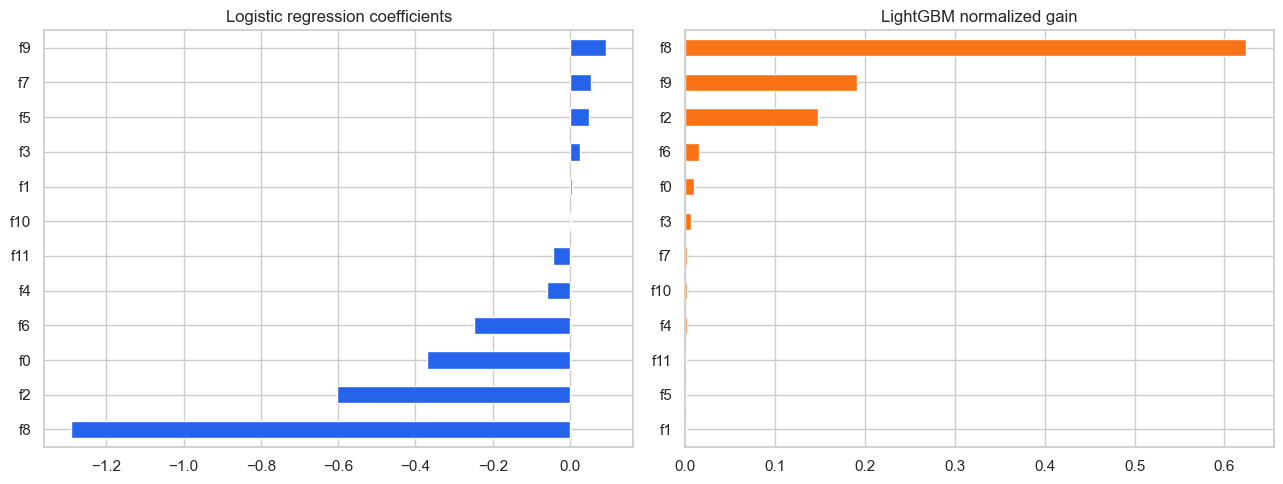

In [9]:
logit_model = models['Logistic regression'].named_steps['model']
logit_importance = pd.Series(logit_model.coef_[0], index=FEATURES, name='standardized_logit_coefficient')

lgbm_model = models['LightGBM']
lgbm_gain = pd.Series(
    lgbm_model.booster_.feature_importance(importance_type='gain'),
    index=FEATURES,
    name='lightgbm_gain',
)
lgbm_gain = lgbm_gain / lgbm_gain.sum()

importance = pd.concat([logit_importance, lgbm_gain], axis=1)
importance['abs_logit_coefficient'] = importance['standardized_logit_coefficient'].abs()
display(importance.sort_values('lightgbm_gain', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
importance.sort_values('standardized_logit_coefficient')['standardized_logit_coefficient'].plot.barh(ax=axes[0], color='#2563eb')
axes[0].set_title('Logistic regression coefficients')
importance.sort_values('lightgbm_gain')['lightgbm_gain'].plot.barh(ax=axes[1], color='#f97316')
axes[1].set_title('LightGBM normalized gain')
plt.tight_layout()
plt.show()

## 9. Response-score deciles

A useful ranking model should place much higher visit rates in its highest-score deciles. This demonstrates predictive segmentation, but it still does not establish heterogeneous causal effects.

,response_decile,users,mean_score,visit_rate,conversion_rate
0,1,19990,0.000599,0.000650,0.000000
1,2,19989,0.000721,0.000200,0.000150
2,3,19989,0.000851,0.000900,0.000050
3,4,19989,0.001158,0.001001,0.000150
4,5,19989,0.002255,0.002201,0.000050
5,6,19989,0.004638,0.004753,0.000150
6,7,19989,0.007971,0.007354,0.000150
7,8,19989,0.018885,0.021312,0.000951
8,9,19989,0.068563,0.064786,0.002351
9,10,19989,0.365220,0.365551,0.025214


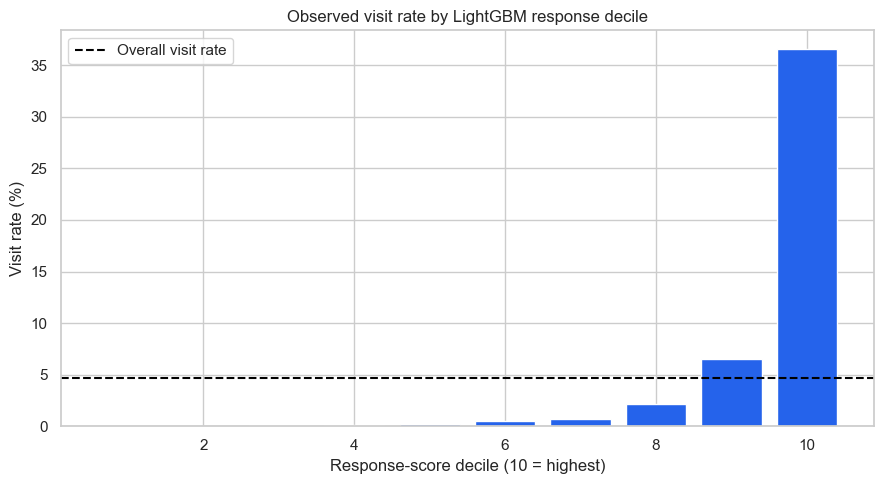

In [10]:
scored = test_predictions.copy()
scored['response_decile'] = pd.qcut(
    scored[best_model_name].rank(method='first'),
    q=10,
    labels=range(1, 11),
)
deciles = scored.groupby('response_decile', observed=True).agg(
    users=('visit', 'size'),
    mean_score=(best_model_name, 'mean'),
    visit_rate=('visit', 'mean'),
    conversion_rate=('conversion', 'mean'),
).reset_index()
display(deciles)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(deciles['response_decile'].astype(int), 100 * deciles['visit_rate'], color='#2563eb')
ax.axhline(100 * y_test.mean(), linestyle='--', color='black', label='Overall visit rate')
ax.set(title=f'Observed visit rate by {best_model_name} response decile', xlabel='Response-score decile (10 = highest)', ylabel='Visit rate (%)')
ax.legend()
plt.tight_layout()
plt.show()

## 10. Causal sanity check: does response targeting create incremental visits?

This is not training a causal model. It evaluates a policy induced by each response score on the untouched randomized test set.

For a top-q policy, let $S_q(X)=1$ identify users in the top q fraction of a score. Because selection uses only pre-treatment X, randomized assignment remains valid inside the selected subgroup. We estimate:

$$\hat\tau(q)=\bar Y_{T=1,S_q=1}-\bar Y_{T=0,S_q=1},\qquad \hat V(q)=q\,\hat\tau(q).$$

$V(q)$ is incremental visit probability per eligible user when only the selected fraction is treated. Multiplying it by 1,000 gives incremental visits per 1,000 eligible users. A random q-fraction policy has expected value $q\times ATE$.

Because the score depends only on pre-treatment X and the test set was not used to train the model, this is an honest randomized policy evaluation. It still has sampling noise.

,selected_share,selected_visit_rate,subgroup_itt_uplift,uplift_ci_95_low,uplift_ci_95_high,policy_value_per_1k_eligible
policy,,,,,,
Top 30% by Random forest,0.299998,0.150299,0.033821,0.026294,0.041347,10.146165
Top 30% by LightGBM,0.299998,0.150549,0.033564,0.026029,0.041099,10.069026
Top 30% by Logistic regression,0.299998,0.148065,0.033211,0.025728,0.040694,9.963201
Random 30%,0.300000,0.046871,0.011501,0.009127,0.013874,3.450152
Top 30% by Dummy prior,0.299998,0.046075,0.010164,0.005837,0.014490,3.049048


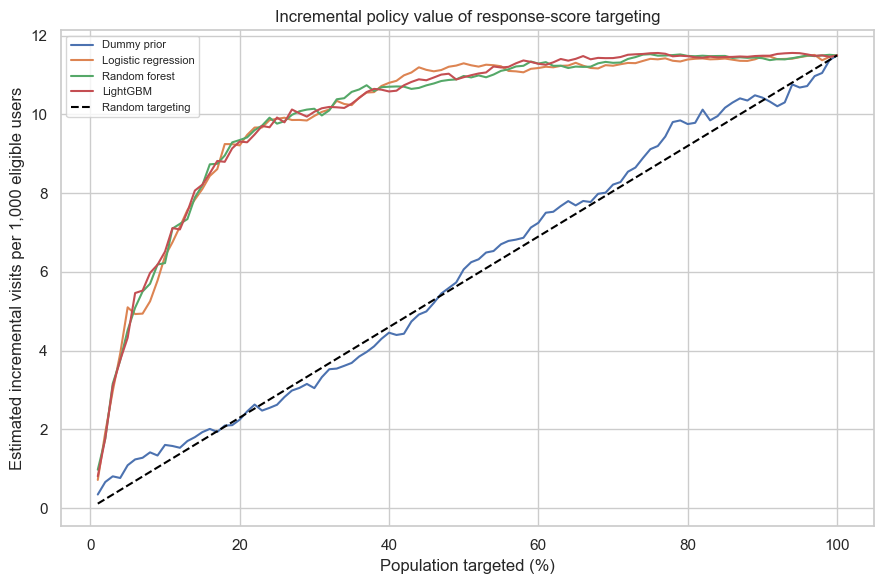

In [11]:
t = scored['treatment'].to_numpy()
y = scored['visit'].to_numpy()
full_test_ate = y[t == 1].mean() - y[t == 0].mean()
full_test_se = np.sqrt(
    y[t == 1].mean() * (1 - y[t == 1].mean()) / (t == 1).sum()
    + y[t == 0].mean() * (1 - y[t == 0].mean()) / (t == 0).sum()
)

fractions = np.linspace(0.01, 1.0, 100)
policy_curves = {}
policy_rows = []

for name in models:
    score = scored[name].to_numpy()
    order = np.argsort(-score, kind='stable')
    sorted_t = t[order]
    sorted_y = y[order]
    cumulative_t_n = np.cumsum(sorted_t)
    cumulative_c_n = np.cumsum(1 - sorted_t)
    cumulative_t_y = np.cumsum(sorted_t * sorted_y)
    cumulative_c_y = np.cumsum((1 - sorted_t) * sorted_y)
    cumulative_t_rate = np.divide(
        cumulative_t_y,
        cumulative_t_n,
        out=np.full(len(scored), np.nan),
        where=cumulative_t_n > 0,
    )
    cumulative_c_rate = np.divide(
        cumulative_c_y,
        cumulative_c_n,
        out=np.full(len(scored), np.nan),
        where=cumulative_c_n > 0,
    )
    cumulative_uplift = cumulative_t_rate - cumulative_c_rate
    cumulative_value = (np.arange(len(scored)) + 1) / len(scored) * cumulative_uplift
    indexes = np.maximum(1, (fractions * len(scored)).astype(int)) - 1
    policy_curves[name] = cumulative_value[indexes]

    selected_n = int(round(0.30 * len(scored)))
    selected = np.zeros(len(scored), dtype=bool)
    selected[order[:selected_n]] = True
    selected_t = t[selected]
    selected_y = y[selected]
    p1 = selected_y[selected_t == 1].mean()
    p0 = selected_y[selected_t == 0].mean()
    uplift = p1 - p0
    uplift_se = np.sqrt(
        p1 * (1 - p1) / (selected_t == 1).sum()
        + p0 * (1 - p0) / (selected_t == 0).sum()
    )
    policy_rows.append({
        'policy': f'Top 30% by {name}',
        'selected_share': selected.mean(),
        'selected_visit_rate': selected_y.mean(),
        'subgroup_itt_uplift': uplift,
        'uplift_ci_95_low': uplift - 1.96 * uplift_se,
        'uplift_ci_95_high': uplift + 1.96 * uplift_se,
        'policy_value_per_1k_eligible': 1000 * selected.mean() * uplift,
    })

policy_rows.append({
    'policy': 'Random 30%',
    'selected_share': 0.30,
    'selected_visit_rate': y.mean(),
    'subgroup_itt_uplift': full_test_ate,
    'uplift_ci_95_low': full_test_ate - 1.96 * full_test_se,
    'uplift_ci_95_high': full_test_ate + 1.96 * full_test_se,
    'policy_value_per_1k_eligible': 1000 * 0.30 * full_test_ate,
})

policy_table = pd.DataFrame(policy_rows).set_index('policy')
display(policy_table.sort_values('policy_value_per_1k_eligible', ascending=False))

fig, ax = plt.subplots(figsize=(9, 6))
for name, values in policy_curves.items():
    ax.plot(100 * fractions, 1000 * values, label=name)
ax.plot(100 * fractions, 1000 * fractions * full_test_ate, '--', color='black', label='Random targeting')
ax.set(
    title='Incremental policy value of response-score targeting',
    xlabel='Population targeted (%)',
    ylabel='Estimated incremental visits per 1,000 eligible users',
)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


In [12]:
best_metrics = metrics.loc[best_model_name]
best_policy = policy_table.loc[f'Top 30% by {best_model_name}']
random_policy = policy_table.loc['Random 30%']
response_policy_names = [f'Top 30% by {name}' for name in models if name != 'Dummy prior']
highest_policy_name = policy_table.loc[response_policy_names, 'policy_value_per_1k_eligible'].idxmax()
highest_policy = policy_table.loc[highest_policy_name]
top_decile = deciles.loc[deciles['response_decile'].astype(int).eq(10)].iloc[0]

display(Markdown(f'''## 11. Automatically generated result summary

- **Best response model by PR-AUC:** {best_model_name}.
- **Discrimination:** ROC-AUC = **{best_metrics.roc_auc:.3f}**; PR-AUC = **{best_metrics.pr_auc:.3f}**, compared with prevalence **{y_test.mean():.3f}**.
- **Concentration:** the highest response decile has visit rate **{top_decile.visit_rate:.1%}**, versus **{y_test.mean():.1%}** overall; top-decile lift = **{best_metrics.top_decile_lift:.2f}x**.
- **Top-30% response policy:** estimated subgroup ITT uplift = **{best_policy.subgroup_itt_uplift:.3%}** (95% CI **{best_policy.uplift_ci_95_low:.3%} to {best_policy.uplift_ci_95_high:.3%}**) and value = **{best_policy.policy_value_per_1k_eligible:.2f} incremental visits per 1,000 eligible users**.
- **Random-30% policy:** expected value = **{random_policy.policy_value_per_1k_eligible:.2f} incremental visits per 1,000 eligible users**.
- The highest observed response-policy value is **{highest_policy_name}** at **{highest_policy.policy_value_per_1k_eligible:.2f} per 1,000**, which need not match the model with best PR-AUC. The small differences among response models are not evidence of causal superiority without uncertainty for paired policy comparisons.

The response model can be highly predictive and may even produce some incremental value, but ROC-AUC/PR-AUC do not optimize or guarantee that value. Stage 3 must model the treatment contrast directly.
'''))

## 11. Automatically generated result summary

- **Best response model by PR-AUC:** LightGBM.
- **Discrimination:** ROC-AUC = **0.945**; PR-AUC = **0.510**, compared with prevalence **0.047**.
- **Concentration:** the highest response decile has visit rate **36.6%**, versus **4.7%** overall; top-decile lift = **7.80x**.
- **Top-30% response policy:** estimated subgroup ITT uplift = **3.356%** (95% CI **2.603% to 4.110%**) and value = **10.07 incremental visits per 1,000 eligible users**.
- **Random-30% policy:** expected value = **3.45 incremental visits per 1,000 eligible users**.
- The highest observed response-policy value is **Top 30% by Random forest** at **10.15 per 1,000**, which need not match the model with best PR-AUC. The small differences among response models are not evidence of causal superiority without uncertainty for paired policy comparisons.

The response model can be highly predictive and may even produce some incremental value, but ROC-AUC/PR-AUC do not optimize or guarantee that value. Stage 3 must model the treatment contrast directly.


## 12. What this stage proves—and does not prove

### Supported conclusions

- Pre-treatment anonymous features contain substantial information about future visits.
- Nonlinear tree boosting can capture response patterns missed by a linear model.
- PR-AUC provides a more demanding view than ROC-AUC under low prevalence.
- Probability calibration and ranking quality must be assessed separately.
- A top-k rule is more relevant to a fixed advertising budget than threshold 0.5.

### Not supported

- Feature importance is not a causal explanation.
- High response probability is not individual uplift.
- A high-AUC model is not necessarily the best treatment policy.
- Anonymous features cannot be labeled as interpretable customer segments.
- Without impression cost and outcome value, the optimal business threshold cannot be calculated.

## 13. Methodological notes

- ROC-AUC measures pairwise ranking, while PR-AUC is more informative about precision-recall tradeoffs for the rare positive class. Accuracy is not useful because predicting no visit for everyone would already be about 95% accurate.
- Unweighted training preserves the observed event prior and supports probability calibration; artificial class rebalancing would require a later probability correction.
- Validation data supports early stopping and development choices, keeping the test split separate from model selection.
- This baseline estimates $P(Y\mid X)$ before the treatment decision. Including treatment would instead estimate a treatment-aware outcome surface $P(Y\mid X,T)$.
- A response policy can create incremental value when response and uplift rankings overlap, but that must be established on randomized outcomes rather than inferred from the predictive loss.
- Feature importance explains variation in predicted visits; it is not a causal interpretation of the features.

## 14. Bridge to Stage 3

The prediction baseline learns one response surface averaged over the experimental treatment mix. Stage 3 will fit separate potential-outcome surfaces:

$$\hat\mu_1(X)=E[Y\mid X,T=1],\qquad \hat\mu_0(X)=E[Y\mid X,T=0],$$

and estimate individual uplift with a T-learner:

$$\hat\tau(X)=\hat\mu_1(X)-\hat\mu_0(X).$$

The decisive comparison will be response-score targeting versus uplift-score targeting on the same untouched randomized evaluation set.